In [1]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = "/content/drive/MyDrive/food-pipeline"
MODEL_SAVE_PATH = f"{DRIVE_PATH}/models/detector"

import os
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
print("Ready")

Mounted at /content/drive
Ready


In [2]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.8 MB/s eta 0:00:00a 0:00:01


In [3]:
import torch
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

GPU: NVIDIA A100-SXM4-40GB



image 1/1 /tmp/test_food.jpg: 640x544 4 pizzas, 1 dining table, 88.0ms
Speed: 14.9ms preprocess, 88.0ms inference, 142.5ms postprocess per image at shape (1, 3, 640, 544)
Detected: pizza (0.52)
Detected: pizza (0.38)
Detected: pizza (0.37)
Detected: dining table (0.37)
Detected: pizza (0.27)
Masks detected: 5


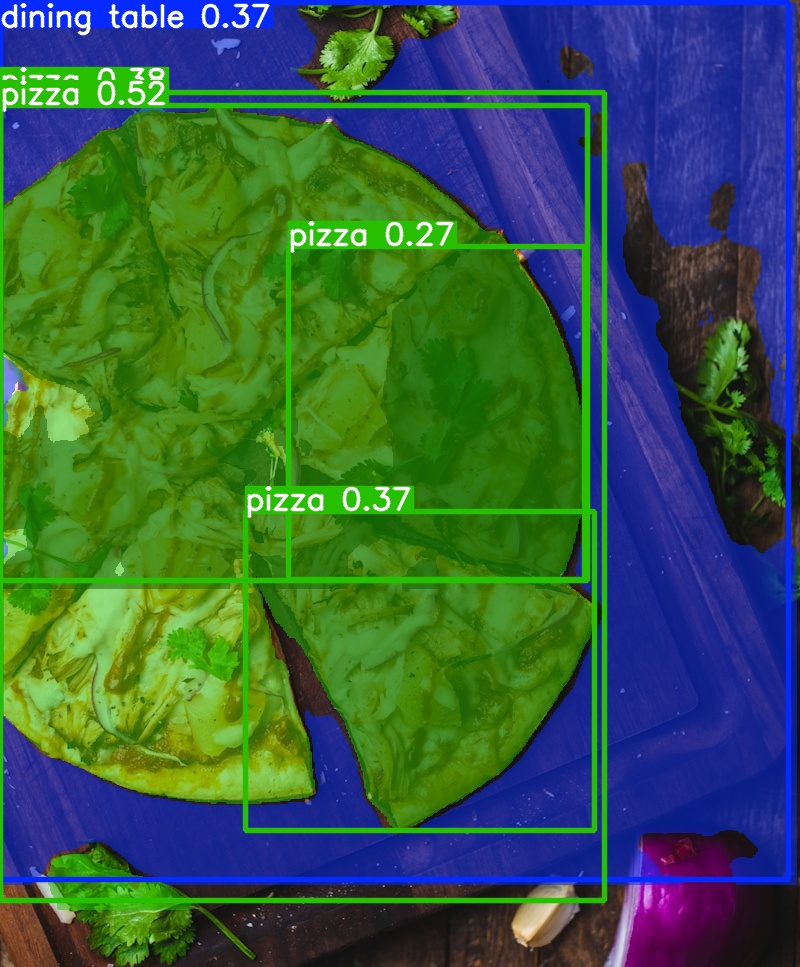

In [7]:
from ultralytics import YOLO
from PIL import Image
from IPython.display import display

model = YOLO("yolov8n-seg.pt")

# Download a food image from a non-blocked source
import subprocess
subprocess.run(["wget", "-q", "-O", "/tmp/test_food.jpg", 
    "https://images.unsplash.com/photo-1565299624946-b28f40a0ae38?w=800"])

results = model("/tmp/test_food.jpg", conf=0.25)
results[0].save(filename="/tmp/yolo_result.jpg")

for r in results:
    if r.boxes is not None:
        for box in r.boxes:
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            label = model.names[cls_id]
            print(f"Detected: {label} ({conf:.2f})")
    if r.masks is None:
        print("No masks detected")
    else:
        print(f"Masks detected: {len(r.masks)}")

display(Image.open("/tmp/yolo_result.jpg"))

In [8]:
# Check FoodSeg103 is available
from datasets import load_dataset

print("Loading FoodSeg103 sample...")
ds = load_dataset("EduardoPacheco/FoodSeg103", split="train[:5]")
print(ds)
print(ds[0].keys())
print(f"Image size: {ds[0]['image'].size}")
print(f"Label type: {type(ds[0]['label'])}")

Loading FoodSeg103 sample...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/351M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/357M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/431M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/115M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4983 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2135 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'label', 'classes_on_image', 'id'],
    num_rows: 5
})
dict_keys(['image', 'label', 'classes_on_image', 'id'])
Image size: (512, 384)
Label type: <class 'PIL.PngImagePlugin.PngImageFile'>


Unique class IDs in mask: [ 0 48 66 90]
Classes on image (IDs): [0, 48, 66, 90]
Dataset features: {'image': Image(mode=None, decode=True), 'label': Image(mode=None, decode=True), 'classes_on_image': List(Value('int64')), 'id': Value('int64')}


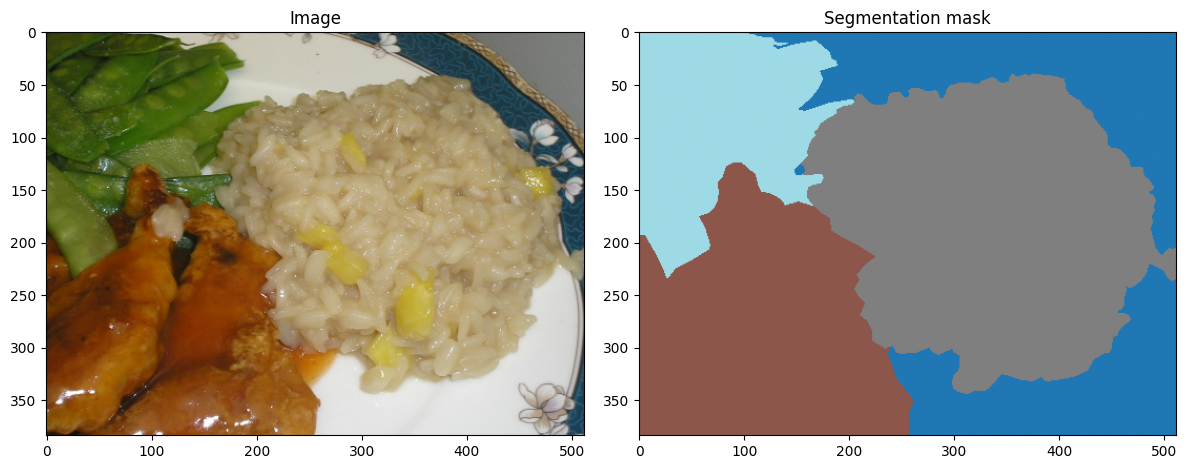

Done


In [10]:
import numpy as np
import matplotlib.pyplot as plt

sample = ds[0]
img = sample['image']
mask = np.array(sample['label'])
classes_on_image = sample['classes_on_image']

print(f"Unique class IDs in mask: {np.unique(mask)}")
print(f"Classes on image (IDs): {classes_on_image}")
print(f"Dataset features: {ds.features}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img)
axes[0].set_title("Image")
axes[1].imshow(mask, cmap='tab20')
axes[1].set_title("Segmentation mask")
plt.tight_layout()
plt.savefig("/tmp/foodseg_sample.jpg")
plt.show()
print("Done")

In [11]:
# Get the class name mapping from the dataset card
from datasets import load_dataset_builder

builder = load_dataset_builder("EduardoPacheco/FoodSeg103")
print(builder.info.features)
print(dir(builder.info))

{'image': Image(mode=None, decode=True), 'label': Image(mode=None, decode=True), 'classes_on_image': List(Value('int64')), 'id': Value('int64')}
['_INCLUDED_INFO_IN_YAML', '__annotations__', '__class__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__post_init__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_dump_info', '_dump_license', '_from_yaml_dict', '_to_yaml_dict', 'builder_name', 'citation', 'config_name', 'copy', 'dataset_name', 'dataset_size', 'description', 'download_checksums', 'download_size', 'features', 'from_dict', 'from_directory', 'from_merge', 'homepage', 'license', 'post_processed', 'post_processing_size', 'size_in_bytes', 'splits', 'supervised_k

In [12]:
# Load a bigger sample and check the class mapping directly
ds_check = load_dataset("EduardoPacheco/FoodSeg103", split="train[:1]")
print(ds_check.features)

# Try to get class names from dataset info
try:
    print(ds_check.info.class_names)
except:
    pass

try:
    print(ds_check.features['classes_on_image'])
except:
    pass

# Check the dataset repo for a label mapping
import requests
r = requests.get("https://huggingface.co/datasets/EduardoPacheco/FoodSeg103/raw/main/README.md")
# Find class names in readme
lines = [l for l in r.text.split('\n') if any(str(i) in l for i in [48, 66, 90])]
print("Relevant README lines:", lines[:10])

{'image': Image(mode=None, decode=True), 'label': Image(mode=None, decode=True), 'classes_on_image': List(Value('int64')), 'id': Value('int64')}
List(Value('int64'))
Relevant README lines: ['| 48 | chicken duck |', '| 66 | rice |', '| 90 | snow peas |']


In [4]:
# FoodSeg103 class ID to name mapping (from dataset paper)
FOODSEG103_CLASSES = {
    0: "background",
    1: "candy", 2: "egg tart", 3: "french fries", 4: "chocolate",
    5: "biscuit", 6: "popcorn", 7: "pudding", 8: "ice cream",
    9: "cheese butter", 10: "cake", 11: "wine", 12: "milkshake",
    13: "coffee", 14: "juice", 15: "milk", 16: "tea",
    17: "almond", 18: "red beans", 19: "cashew", 20: "dried cranberries",
    21: "soy", 22: "walnut", 23: "peanut", 24: "egg",
    25: "apple", 26: "date", 27: "apricot", 28: "avocado",
    29: "banana", 30: "strawberry", 31: "cherry", 32: "blueberry",
    33: "raspberry", 34: "mango", 35: "olives", 36: "peach",
    37: "lemon", 38: "pear", 39: "fig", 40: "pineapple",
    41: "grape", 42: "kiwi", 43: "melon", 44: "orange",
    45: "watermelon", 46: "steak", 47: "pork", 48: "chicken duck",
    49: "sausage", 50: "fried meat", 51: "lamb", 52: "sauce",
    53: "crab", 54: "fish", 55: "shellfish", 56: "shrimp",
    57: "soup", 58: "bread", 59: "corn", 60: "hamburg",
    61: "pizza", 62: "hanamaki baozi", 63: "wonton dumplings",
    64: "tong sui", 65: "tart", 66: "rice", 67: "tofu",
    68: "eggplant", 69: "potato", 70: "garlic", 71: "spring onion",
    72: "snap peas", 73: "celery", 74: "mushroom", 75: "eggplant",
    76: "green beans", 77: "tomato", 78: "hot pepper", 79: "squash",
    80: "yellow squash", 81: "broccoli", 82: "onion", 83: "cabbage",
    84: "pumpkin", 85: "cucumber", 86: "white radish", 87: "carrot",
    88: "asparagus", 89: "bamboo shoots", 90: "bean sprouts",
    91: "turnip", 92: "green pepper", 93: "okra", 94: "lettuce",
    95: "pumpkin leaf", 96: "seaweed", 97: "noodles", 98: "rice noodles",
    99: "pasta", 100: "dumpling", 101: "taro", 102: "chips",
    103: "anything_else"
}

# Confirm our first sample
sample = ds[0]
classes_on_image = sample['classes_on_image']
print("Classes in first image:")
for cid in classes_on_image:
    print(f"  ID {cid}: {FOODSEG103_CLASSES.get(cid, 'unknown')}")

print(f"\nTotal classes in mapping: {len(FOODSEG103_CLASSES)}")

NameError: name 'ds' is not defined

In [5]:
import os
import numpy as np
from PIL import Image
from datasets import load_dataset
from tqdm import tqdm

# Output directories
YOLO_DIR = "/content/yolo_foodseg"
for split in ["train", "val"]:
    os.makedirs(f"{YOLO_DIR}/images/{split}", exist_ok=True)
    os.makedirs(f"{YOLO_DIR}/labels/{split}", exist_ok=True)

def mask_to_yolo_polygons(mask_array, class_id, img_w, img_h):
    """Convert a binary mask to YOLO polygon format."""
    import cv2
    binary = (mask_array > 0).astype(np.uint8)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    polygons = []
    for contour in contours:
        if cv2.contourArea(contour) < 100:  # skip tiny regions
            continue
        # Simplify contour
        epsilon = 0.005 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)
        if len(approx) < 3:
            continue
        # Normalize coordinates
        points = approx.reshape(-1, 2)
        normalized = []
        for x, y in points:
            normalized.extend([x / img_w, y / img_h])
        polygons.append(f"{class_id} " + " ".join(f"{v:.6f}" for v in normalized))
    
    return polygons

def convert_split(split_name, hf_split, max_samples=None):
    ds = load_dataset("EduardoPacheco/FoodSeg103", split=hf_split)
    if max_samples:
        ds = ds.select(range(min(max_samples, len(ds))))
    
    print(f"Converting {split_name}: {len(ds)} images...")
    skipped = 0
    
    for idx, sample in enumerate(tqdm(ds)):
        img = sample['image'].convert("RGB")
        mask = np.array(sample['label'])
        img_w, img_h = img.size
        
        # Save image
        img_path = f"{YOLO_DIR}/images/{split_name}/{idx:05d}.jpg"
        img.save(img_path, quality=95)
        
        # Build food mask — everything except background (class 0)
        food_mask = (mask > 0).astype(np.uint8)
        
        label_lines = []
        
        # Food regions → class 1
        if food_mask.sum() > 0:
            polygons = mask_to_yolo_polygons(food_mask, class_id=1, 
                                              img_w=img_w, img_h=img_h)
            label_lines.extend(polygons)
        
        # Write label file (even if empty — YOLO needs it)
        label_path = f"{YOLO_DIR}/labels/{split_name}/{idx:05d}.txt"
        with open(label_path, "w") as f:
            f.write("\n".join(label_lines))
        
        if not label_lines:
            skipped += 1
    
    print(f"Done. Skipped {skipped} images with no food regions.")

# Convert both splits
convert_split("train", "train")
convert_split("val", "validation")

print("\nConversion complete.")
print(f"Train images: {len(os.listdir(f'{YOLO_DIR}/images/train'))}")
print(f"Val images: {len(os.listdir(f'{YOLO_DIR}/images/val'))}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/351M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/357M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/431M [00:00<?, ?B/s]

...

Converting train: 4983 images...


100%|██████████| 4983/4983 [01:53<00:00, 43.84it/s]


Done. Skipped 0 images with no food regions.
Converting val: 2135 images...


100%|██████████| 2135/2135 [00:13<00:00, 156.66it/s]

Done. Skipped 0 images with no food regions.

Conversion complete.
Train images: 4983
Val images: 2135


In [6]:
yaml_content = f"""
path: {YOLO_DIR}
train: images/train
val: images/val

nc: 2
names:
  0: plate
  1: food
"""

with open(f"{YOLO_DIR}/foodseg.yaml", "w") as f:
    f.write(yaml_content)

print("YAML config saved:")
print(yaml_content)

YAML config saved:

path: /content/yolo_foodseg
train: images/train
val: images/val

nc: 2
names:
  0: plate
  1: food



In [7]:
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")

results = model.train(
    data=f"{YOLO_DIR}/foodseg.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    patience=10,
    save=True,
    device=0,
    project=MODEL_SAVE_PATH,
    name="yolo_food",
    exist_ok=True,
    verbose=True
)

print(f"\nBest mAP50: {results.results_dict.get('metrics/mAP50(B)', 'N/A')}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_foodseg/foodseg.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7

In [8]:
import shutil

best_weights = f"{MODEL_SAVE_PATH}/yolo_food/weights/best.pt"
dest = f"{MODEL_SAVE_PATH}/yolov8n_food_best.pt"

if os.path.exists(best_weights):
    shutil.copy(best_weights, dest)
    print(f"Best weights saved to Drive: {dest}")
else:
    print("best.pt not found — check training output")

Best weights saved to Drive: /content/drive/MyDrive/food-pipeline/models/detector/yolov8n_food_best.pt
